In [8]:
# 현재 프로젝트 환경에서 TensorFlow GPU 사용 가능 여부를 확인합니다.
# 중요: TensorFlow는 CUDA 라이브러리 경로가 잡힌 상태로 프로세스가 시작되어야 GPU를 인식합니다.
# 따라서 현재 커널 직접 import와 별도로, 올바른 LD_LIBRARY_PATH를 넣은 subprocess로 GPU 감지를 확인합니다.
from pathlib import Path
import os
import subprocess
import sys

PROJECT_ROOT_FOR_GPU = Path.cwd().resolve()
if PROJECT_ROOT_FOR_GPU.name == "notebooks":
    PROJECT_ROOT_FOR_GPU = PROJECT_ROOT_FOR_GPU.parent

PYTHON_EXECUTABLE = PROJECT_ROOT_FOR_GPU / ".venv" / "bin" / "python"
NVIDIA_ROOT = PROJECT_ROOT_FOR_GPU / ".venv" / "lib" / "python3.10" / "site-packages" / "nvidia"
NVIDIA_LIB_DIRS = sorted(str(path) for path in NVIDIA_ROOT.glob("*/lib"))

tensorflow_env = os.environ.copy()
tensorflow_env["LD_LIBRARY_PATH"] = ":".join([
    *NVIDIA_LIB_DIRS,
    "/usr/lib/wsl/lib",
    tensorflow_env.get("LD_LIBRARY_PATH", ""),
])

gpu_check_code = """
import json
import os
import tensorflow as tf
physical_gpus = tf.config.list_physical_devices('GPU')
logical_gpus = tf.config.list_logical_devices('GPU')
info = {
    'tensorflow_version': tf.__version__,
    'gpu_available': len(physical_gpus) > 0,
    'physical_gpus': [gpu.name for gpu in physical_gpus],
    'logical_gpus': [gpu.name for gpu in logical_gpus],
    'ld_library_path_set': bool(os.environ.get('LD_LIBRARY_PATH')),
}
print(json.dumps(info, ensure_ascii=False, indent=2))
"""

result = subprocess.run(
    [str(PYTHON_EXECUTABLE), "-c", gpu_check_code],
    cwd=PROJECT_ROOT_FOR_GPU,
    env=tensorflow_env,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(result.stdout)
if result.returncode != 0:
    raise RuntimeError(f"GPU 확인 subprocess가 실패했습니다. returncode={result.returncode}")

if "tensorflow" in sys.modules:
    print("주의: 현재 노트북 커널에서 TensorFlow가 이미 import되어 있으면 커널 자체의 GPU 인식은 바뀌지 않습니다.")
    print("GPU로 학습하려면 커널을 재시작하거나, 아래 학습 셀처럼 tensorflow_env를 subprocess에 넘겨 실행하십시오.")


I0000 00:00:1780647939.673523   96056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780647939.769455   96056 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780647941.544569   96056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780647942.533607   96056 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel bi

# SilverWalk MLP 모델 실행

전처리된 `data/processed/original_train_*_preprocessed.csv` 파일을 사용해 MLP 모델을 학습하고 결과를 확인하는 노트북입니다.

기본 설정은 빠른 동작 확인용입니다. 전체 데이터로 학습하려면 아래 설정 셀에서 `LIMIT_ROWS = None`, `EPOCHS = 100`으로 바꾸십시오.

In [9]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT

PosixPath('/home/huichan/SPARV/SilverWalk')

## 1. 학습 설정

In [10]:
# 빠른 실행 기본값입니다. 전체 학습은 LIMIT_ROWS=None, EPOCHS=100으로 바꾸십시오.
LIMIT_ROWS = None
EPOCHS = 100
BATCH_SIZE = 256
DEVICE = "auto"  # "auto", "gpu", "cpu" 중 선택
MIXED_PRECISION = False

RUN_NAME = "mlp_risk_notebook_smoke"

model_path = PROJECT_ROOT / "artifacts" / "models" / f"{RUN_NAME}.keras"
metrics_path = PROJECT_ROOT / "artifacts" / "reports" / f"{RUN_NAME}_metrics.json"
history_path = PROJECT_ROOT / "artifacts" / "reports" / f"{RUN_NAME}_history.csv"
predictions_path = PROJECT_ROOT / "artifacts" / "predictions" / f"{RUN_NAME}_test_predictions.csv"

{
    "LIMIT_ROWS": LIMIT_ROWS,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "DEVICE": DEVICE,
    "MIXED_PRECISION": MIXED_PRECISION,
    "model_path": str(model_path.relative_to(PROJECT_ROOT)),
    "metrics_path": str(metrics_path.relative_to(PROJECT_ROOT)),
    "history_path": str(history_path.relative_to(PROJECT_ROOT)),
    "predictions_path": str(predictions_path.relative_to(PROJECT_ROOT)),
}

{'LIMIT_ROWS': None,
 'EPOCHS': 100,
 'BATCH_SIZE': 256,
 'DEVICE': 'auto',
 'MIXED_PRECISION': False,
 'model_path': 'artifacts/models/mlp_risk_notebook_smoke.keras',
 'metrics_path': 'artifacts/reports/mlp_risk_notebook_smoke_metrics.json',
 'history_path': 'artifacts/reports/mlp_risk_notebook_smoke_history.csv',
 'predictions_path': 'artifacts/predictions/mlp_risk_notebook_smoke_test_predictions.csv'}

## 2. 전처리 산출물 확인

In [11]:
required_paths = [
    PROJECT_ROOT / "data" / "processed" / "original_train_train_preprocessed.csv",
    PROJECT_ROOT / "data" / "processed" / "original_train_val_preprocessed.csv",
    PROJECT_ROOT / "data" / "processed" / "original_train_test_preprocessed.csv",
    PROJECT_ROOT / "artifacts" / "preprocessors" / "original_train_preprocess_config.json",
]

path_check = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else None,
        }
        for path in required_paths
    ]
)

path_check

,path,exists,size_mb
0,data/processed/original_train_train_preprocess...,True,592.13
1,data/processed/original_train_val_preprocessed...,True,126.88
2,data/processed/original_train_test_preprocesse...,True,126.90
3,artifacts/preprocessors/original_train_preproc...,True,0.02


In [12]:
missing_paths = path_check.loc[~path_check["exists"], "path"].tolist()
if missing_paths:
    raise FileNotFoundError(
        "전처리 산출물이 없습니다. 먼저 `.venv/bin/python scripts/data/preprocess_original_train_data.py`를 실행하십시오. "
        f"missing={missing_paths}"
    )

with (PROJECT_ROOT / "artifacts" / "preprocessors" / "original_train_preprocess_config.json").open("r", encoding="utf-8") as file:
    preprocess_config = json.load(file)

{
    "feature_count": len(preprocess_config["feature_columns"]),
    "excluded_model_columns": preprocess_config["excluded_model_columns"],
    "위도_in_features": "위도" in preprocess_config["feature_columns"],
    "경도_in_features": "경도" in preprocess_config["feature_columns"],
    "위험도_in_features": "위험도" in preprocess_config["feature_columns"],
}

{'feature_count': 102,
 'excluded_model_columns': ['POINT_ID', '위도', '경도', '위험도'],
 '위도_in_features': False,
 '경도_in_features': False,
 '위험도_in_features': False}

## 3. 모델 학습 실행

In [13]:
cmd = [
    str(PROJECT_ROOT / ".venv" / "bin" / "python"),
    str(PROJECT_ROOT / "scripts" / "train" / "train_mlp.py"),
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--device", DEVICE,
    "--verbose", "2",
    "--model-path", str(model_path),
    "--metrics-path", str(metrics_path),
    "--history-path", str(history_path),
    "--predictions-path", str(predictions_path),
]

if LIMIT_ROWS is not None:
    cmd.extend(["--limit-rows", str(LIMIT_ROWS)])

if MIXED_PRECISION:
    cmd.append("--mixed-precision")

print(" ".join(cmd))

/home/huichan/SPARV/SilverWalk/.venv/bin/python /home/huichan/SPARV/SilverWalk/scripts/train/train_mlp.py --epochs 100 --batch-size 256 --device auto --verbose 2 --model-path /home/huichan/SPARV/SilverWalk/artifacts/models/mlp_risk_notebook_smoke.keras --metrics-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_risk_notebook_smoke_metrics.json --history-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_risk_notebook_smoke_history.csv --predictions-path /home/huichan/SPARV/SilverWalk/artifacts/predictions/mlp_risk_notebook_smoke_test_predictions.csv


In [14]:
# 학습 로그를 에포크 단위로 출력합니다.
# Keras verbose=2 설정으로 batch 진행 막대는 숨기고 epoch별 결과만 확인합니다.
live_env = tensorflow_env.copy()
live_env["PYTHONUNBUFFERED"] = "1"

process = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    env=live_env,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
)

log_lines = []
assert process.stdout is not None
for line in process.stdout:
    print(line, end="")
    log_lines.append(line)

returncode = process.wait()
training_log = "".join(log_lines)
if returncode != 0:
    raise RuntimeError(f"학습 스크립트가 실패했습니다. returncode={returncode}")


I0000 00:00:1780647943.535497   96096 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780647943.560651   96096 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780647944.240602   96096 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780647944.799646   96096 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel bi

## 4. 학습 결과 확인

In [15]:
with metrics_path.open("r", encoding="utf-8") as file:
    metrics = json.load(file)

metrics_summary = {
    "feature_count": metrics["feature_count"],
    "train_rows": metrics["train_rows"],
    "val_rows": metrics["val_rows"],
    "test_rows": metrics["test_rows"],
    "device": metrics["device"],
    "risk_scale": metrics["risk_scale"],
    "log_scale": metrics["log_scale"],
    "risk_threshold_counts": metrics["risk_threshold_counts"],
}

metrics_summary

{'feature_count': 102,
 'train_rows': 315464,
 'val_rows': 67599,
 'test_rows': 67600,
 'device': {'requested_device': 'auto',
  'active_device': 'gpu',
  'physical_gpus': ['/physical_device:GPU:0'],
  'logical_gpus': ['/device:GPU:0'],
  'memory_growth': True,
  'mixed_precision': False},
 'risk_scale': {'mae': 0.5077398525822691,
  'rmse': 2.7885660774607652,
  'r2': 0.5852713100404674},
 'log_scale': {'mae': 0.1627978655537923,
  'rmse': 0.3592892601164988,
  'r2': 0.5302731674582979},
 'risk_threshold_counts': {'actual_gt_0': 13482,
  'pred_gt_0': 67457,
  'actual_gt_50': 105,
  'pred_gt_50': 33}}

In [16]:
history = pd.read_csv(history_path)
history

,loss,mae,rmse,val_loss,val_mae,val_rmse,learning_rate
0,0.107134,0.281209,0.526958,0.088659,0.238251,0.477138,0.001000
1,0.089745,0.234391,0.480787,0.086095,0.229634,0.468204,0.001000
2,0.087342,0.228790,0.472224,0.084482,0.230083,0.461138,0.001000
3,0.084784,0.223608,0.463073,0.082077,0.225663,0.452988,0.001000
4,0.082406,0.219496,0.454603,0.079432,0.217561,0.446258,0.001000
5,0.080503,0.216006,0.447537,0.077644,0.212492,0.438982,0.001000
6,0.078826,0.212866,0.441549,0.075661,0.202598,0.431323,0.001000
7,0.077020,0.210000,0.435137,0.074499,0.195858,0.428868,0.001000
8,0.075549,0.207375,0.429793,0.072829,0.194232,0.421959,0.001000
9,0.074341,0.205159,0.425043,0.071917,0.190153,0.419800,0.001000


<Axes: title={'center': 'MLP loss'}>

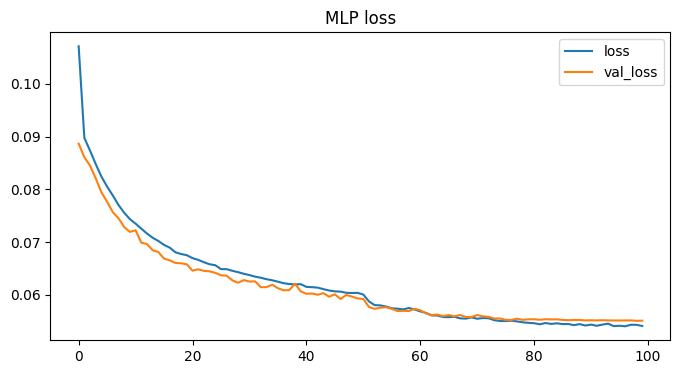

In [17]:
history[["loss", "val_loss"]].plot(figsize=(8, 4), title="MLP loss")

## 5. 예측 결과 확인

In [18]:
predictions = pd.read_csv(predictions_path)
predictions.head()

,POINT_ID,위도,경도,위험도,위험도_log1p,pred_위험도_log1p,pred_위험도
0,1,37.590982,126.992616,0.000,0.000000,0.003743,0.003750
1,8,37.590081,126.991800,0.000,0.000000,0.004380,0.004389
2,9,37.590242,126.991611,0.000,0.000000,0.006312,0.006332
3,25,37.583259,127.000080,0.000,0.000000,0.047688,0.048843
4,29,37.582845,126.999079,37.008,3.637797,3.542728,33.561060


In [19]:
predictions[["위험도", "pred_위험도", "위험도_log1p", "pred_위험도_log1p"]].describe()

,위험도,pred_위험도,위험도_log1p,pred_위험도_log1p
count,67600.000000,67600.000000,67600.000000,67600.000000
mean,0.663838,0.374136,0.175981,0.146217
std,4.330142,2.581682,0.524233,0.363250
min,0.000000,0.000000,0.000000,-0.139655
25%,0.000000,0.037707,0.000000,0.037013
50%,0.000000,0.054065,0.000000,0.052654
75%,0.000000,0.098733,0.000000,0.094158
max,221.376000,125.488790,5.404370,4.840154


Text(0, 0.5, 'predicted 위험도')

/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) 

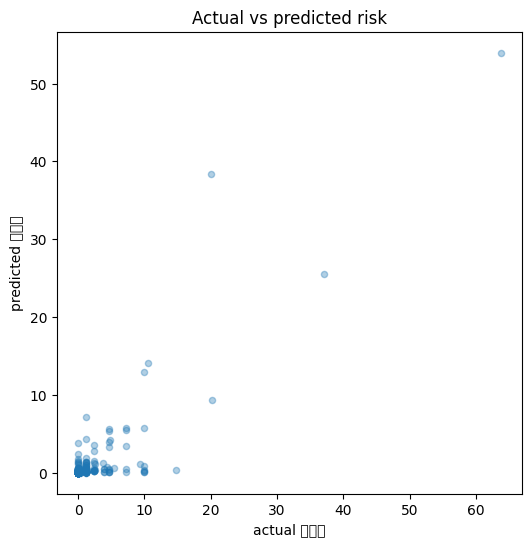

In [20]:
sample = predictions.sample(min(1000, len(predictions)), random_state=42)
ax = sample.plot.scatter(x="위험도", y="pred_위험도", alpha=0.35, figsize=(6, 6), title="Actual vs predicted risk")
ax.set_xlabel("actual 위험도")
ax.set_ylabel("predicted 위험도")

## 6. 저장된 모델 로드 확인

In [21]:
import tensorflow as tf

model = tf.keras.models.load_model(model_path)
model.summary()

I0000 00:00:1780648293.227640   91712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780648293.256908   91712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780648294.012536   91712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780648294.497376   91712 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please mak

Model: "silverwalk_mlp_risk"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 102)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        13,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ risk_log1p (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,197 (282.02 KB)

 Trainable params: 23,937 (93.50 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 47,876 (187.02 KB)